# Step 1: Single-Sample SCIMAP Processing (No PC)

**Purpose:** Process one multiplexed imaging sample (from MCMICRO output) through the full SCIMAP spatial proteomics workflow — from raw quantification to phenotyped, ROI-filtered AnnData ready for downstream comparison.

## What this notebook does

1. **Configuration & setup** — Define sample ID, genotype, paths, and marker lists. 
   All downstream file paths are built automatically from these settings.

2. **Data loading** — Import the MCMICRO cellRing quantification CSV and convert it to 
   an AnnData object (the core data structure for SCIMAP). A checkpoint `.h5ad` file is 
   saved immediately.

3. **Visual QC** — Open the tissue image in napari for manual inspection; generate 2D 
   density plots of marker pairs to assess signal distributions before gating.

4. **Gating & rescaling** — Load manually-set gate thresholds (from Minerva Gater), then 
   rescale all marker intensities to a 0–1 scale relative to each gate.

5. **Phenotyping** — Apply rule-based cell-type assignment using a phenotyping CSV that 
   defines marker logic for each cell type. Validate results with a heatmap and a napari 
   overlay.

6. **ROI selection** — Interactively draw 4 regions of interest (ROIs) in napari, then 
   combine them into a single unified ROI column and filter to keep only cells within 
   drawn regions.

7. **Cleanup & export** — Remove unclassified ("Unknown") cells, add genotype metadata, 
   and save the final AnnData as `.h5ad`. Generate a stacked bar chart comparing cell-type 
   composition across ROIs.

## Inputs
- `<sample_id>--unmicst_cellRing.csv` — per-cell marker quantification from MCMICRO
- `<sample_id>.ome.tif` — registered tissue image
- `<sample_id>_gates.csv` — manual gate thresholds (one per marker)
- `phenotyping_workflow_simple.csv` — cell-type assignment rules

## Outputs
- `adata_<sample_id>.h5ad` — final processed AnnData (phenotyped, ROI-filtered, genotype-labeled)
- `isogenic_phenotypecounts_<sample_id>.csv` — cell-type count table
- Validation plots (heatmap, stacked bar chart)

## Requirements
- Python 3.10 environment with: scimap, anndata, scanpy, napari, tifffile, pandas, numpy, seaborn, matplotlib
- Manual steps: gate thresholds must be set in Minerva Gater before the rescaling step; ROIs are drawn interactively in napari

In [2]:
## Import all required libraries
import sys # system utilities, not really used directly
import os # file navigation on your computer
import pandas as pd # handles tables (dataframes)
import anndata as ad # data structure used by scimap
import scanpy as sc # single-cell analysis funcs
import seaborn as sns; sns.set(color_codes=True) # makes Seaborn color defaults nicer
import matplotlib.pyplot as plt # plotting
from scipy import stats # statistics funcs
import numpy as np # arrays and math

import warnings 
warnings.filterwarnings('ignore') # hide the warnings to keep outputs cleaner

# Import Scimap
import scimap as sm

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


In [3]:

# -------------------------------------------------------------------
## ‼️ UPDATE‼️ this cell every time you run a new sample
# -------------------------------------------------------------------
# Who/what is this sample
sample_id = 'BDBAT0085' # Update your sample barcode -- must match MCMICRO folder name
exp = 'test_run' # Update your experiment name, used in output file names
date = '26_06_03' # Update date to match
genotype  = 'test_run' # Update exp. condition

# Where is the data
working_dir = 'C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis' # Please update root folder containing all the samples

# How many ROIs to draw
n_rois = 4 # Update to match how many you want. ‼️NOTE‼️ if you change this you also need to:
           #  1) add/remove ROI drawing cells accordingly
            #  2) update the np.where block in the 4th to last cell accordingly. (tricky, can avoid by just keeping 4 ROIs)

# Which markers to show in validation heatmap? 
heatmap_markers = ['HSV', 'VSV-G', 'V5', 'NWS', 'Ollas', 'S', 'HA', 'CD45', 'C', 'PanCK', 'CD4', 'CD8a', 'PDPN', 'F480', 'CD161c']  # Update if needed

# Print a summary to make sure everything looks right 
print("Configuration summary below:")
print(f"  Sample    : {sample_id}")
print(f"  Genotype  : {genotype}")
print(f"  Root directory  : {working_dir}")

Configuration summary below:
  Sample    : BDBAT0085
  Genotype  : test_run
  Root directory  : C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis


In [4]:
# -------------------------------------------------------------------
## Everything below built automatically, don't edit!
# -------------------------------------------------------------------

# Output folder names
analysis_dir  = os.path.join(working_dir, 'analysis') # .join() handles slashes better, more clean and easy
counts_dir    = os.path.join(analysis_dir, 'scimap_results', 'counts_scimap')
adata_out_dir = os.path.join(analysis_dir, 'scimap_results', 'adata_tocombine')

# Input file path names built from sample_id so you don't have to edit manually
cellring_csv     = os.path.join(working_dir, sample_id, 'quantification',
                                f'{sample_id}--unmicst_cellRing.csv')
tif_path         = os.path.join(working_dir, sample_id, 'registration',
                                f'{sample_id}.ome.tif')
gates_file       = os.path.join(working_dir, sample_id,
                                f'{sample_id}_gates.csv')
phenotyping_file = os.path.join(working_dir, 'phenotyping_workflow_simple.csv')

# Output file path names
counts_csv       = os.path.join(counts_dir,f'isogenic_phenotypecounts_{sample_id}.csv')
adata_final      = os.path.join(adata_out_dir,f'adata_{sample_id}.h5ad')
adata_checkpoint = os.path.join(analysis_dir,f'{date}{exp}.h5ad')

# Check that all required input file names actually exist on disk

print("Checking input files:")
all_good = True
for label, path in [('CellRing CSV', cellring_csv),
                    ('TIF image',    tif_path),
                    ('Gates file',   gates_file),
                    ('Phenotyping',  phenotyping_file)]:
    if os.path.exists(path): # checks if file/folder actually exists on your computer - True if yes, False if not
        print(f"{label} is here!")
    else:
        print(f" {label} is missing")
        print(f"Expected at: {path}")
        all_good = False

if all_good:
    print("\n All files found. Ready to run!")
else:
    print("\n Please fix missing files before continuing.")

Checking input files:
CellRing CSV is here!
TIF image is here!
Gates file is here!
Phenotyping is here!

 All files found. Ready to run!


In [5]:
## Create all the actual output folder PATHS

for folder in [analysis_dir, counts_dir, adata_out_dir]:
    os.makedirs(folder, exist_ok=True) # create the folder; if it already exists, move on
    print(f"Ready: {folder}")
    
# Navigate to the working directory and set it
os.chdir(working_dir)
print(f"\nWorking directory set to {os.getcwd()}") # prints whatever the current working directory has been set to to make sure it worked

Ready: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\analysis
Ready: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\analysis\scimap_results\counts_scimap
Ready: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\analysis\scimap_results\adata_tocombine

Working directory set to C:\Users\kelse\OneDrive - The Mount Sinai Hospital\02_Presentations\Platforma_MCMICRO_Tutorial_Docs\MCMICRO_Python_Analysis


In [6]:
## Load the cellRing CSV and convert to AnnData (scimap format)

print(f"Loading: {cellring_csv}")

adata = sm.pp.mcmicro_to_scimap([cellring_csv]) # scimap preprocessing feature that converts the MCMICRO csv to anndata

# Save a checkpoint immediately after loading so if anything crashes later you can reload this .h5ad file
os.chdir(analysis_dir)
adata.write(adata_checkpoint, compression=None) # save adata_checkpoint to computer (compression=None faster for big files)

print(f"\n Data loaded and saved!")
print(f"Cells detected: {adata.n_obs:,}") # number of observations (cells)
print(f"Markers: {adata.n_vars}") #  number of variables (markers)
print(f"Marker names: {list(adata.var_names)}") # list of marker names
print(f"Checkpoint: {adata_checkpoint}")

Loading: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\BDBAT0085\quantification\BDBAT0085--unmicst_cellRing.csv
Loading BDBAT0085--unmicst_cellRing.csv

 Data loaded and saved!
Cells detected: 399,071
Markers: 18
Marker names: ['AF488', 'AF555', 'AF647', 'HSV', 'VSV-G', 'V5', 'NWS', 'Ollas', 'S', 'HA', 'CD45', 'C', 'PanCK', 'CD4', 'CD8a', 'PDPN', 'F480', 'CD161c']
Checkpoint: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\analysis\26_06_03test_run.h5ad


In [7]:
# ----------------------------
# Renaming cell labels for more clairty + consistency
# ----------------------------

# Rename imageid column for ease
# Ensure the new name matches the CSV filename used to generate adata
rename = {sample_id: [f'{sample_id}--unmicst_cellRing']}
adata = sm.hl.rename(adata, rename, from_column='imageid', to_column='imageid') # scimamp function takes dictionary new name : old name and does find and replace
                                                                                # staying within the imageid column
print(f"imageid shortened to: '{sample_id}'")

# Add Treatment_Group column 
rename = {exp: [sample_id]}
adata = sm.hl.rename(adata, rename, from_column='imageid', to_column='Treatment_Group') # filling in a new treatment_group column with exp variable
print(f"Treatment_Group column added: '{exp}'")

# Clean up the cell row names (index)
indices = (adata.obs.index.str.slice(0, len(sample_id)) + "_" + adata.obs.index.str.slice((len(sample_id) + 19),)) # applied to every string (cell name) in the list
adata.obs.index = indices # list of row labels/names for each cell
print(f"Cell names cleaned, example: '{adata.obs.index[0]}'")

# Save updated adata, same checkpoint file but now w/ clean labels

os.chdir(analysis_dir)
adata.write(adata_checkpoint, compression=None)
print(f"\nCheckpoint saved!")
adata.obs # View adata


Renaming BDBAT0085--unmicst_cellRing to BDBAT0085
imageid shortened to: 'BDBAT0085'
Renaming BDBAT0085 to test_run
Treatment_Group column added: 'test_run'
Cell names cleaned, example: 'BDBAT0085_1'

Checkpoint saved!


,X_centroid,Y_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,CellID,imageid,Treatment_Group
BDBAT0085_1,3863.912752,638.174497,149.0,14.330963,13.249329,0.381122,0.931250,0.764103,1.471999,1,BDBAT0085,test_run
BDBAT0085_2,3465.516908,714.526570,207.0,18.833414,14.001783,0.668787,0.936652,0.739286,-1.356049,2,BDBAT0085,test_run
BDBAT0085_3,3050.022422,1033.394619,223.0,18.459338,15.380374,0.552967,0.961207,0.819853,-0.906260,3,BDBAT0085,test_run
BDBAT0085_4,2506.576471,1764.158824,170.0,18.075014,12.167323,0.739500,0.949721,0.666667,-0.671361,4,BDBAT0085,test_run
BDBAT0085_5,2510.019417,1772.718447,103.0,16.276087,8.575708,0.849933,0.880342,0.525510,-0.846072,5,BDBAT0085,test_run
...,...,...,...,...,...,...,...,...,...,...,...,...
BDBAT0085_399067,4708.460526,16801.184211,228.0,23.016359,12.687695,0.834342,0.942149,0.762542,-1.390851,399067,BDBAT0085,test_run
BDBAT0085_399068,4111.453125,16804.718750,128.0,14.773151,11.144651,0.656432,0.914286,0.711111,-1.552599,399068,BDBAT0085,test_run
BDBAT0085_399069,4229.641221,16814.541985,131.0,13.881165,12.030667,0.498847,0.935714,0.719780,0.465510,399069,BDBAT0085,test_run
BDBAT0085_399070,4343.358289,16822.614973,187.0,19.559901,12.193644,0.781903,0.944444,0.820175,-1.429099,399070,BDBAT0085,test_run


## Inspect distribution of markers in raw image

Before we assign cell type markers, we will first review the image in Napari image viewer to do a quick visual QC that the image loads and the markers are visible. 

We will also make a density plot of marker pairs to assess signal distributions. This is another visual QC to ensure mutually exclusive markers and co-expressing markers follow expected distributions. 

In [8]:
#Open napari to see and inspect raw tissue image before gating

# Set the working directory and select which sample(s) to view in Napari
os.chdir(working_dir)

subset_to_use = adata.obs['imageid'].unique()[0] # returns the first unique value in the imageid column, if only have one sample this is just the sampleid

marker_names = list(adata.var_names) # convert marker names stored in adata from anndata to normal list

print(f"Opening napari for {subset_to_use}")
print(f"Image: {tif_path}")
print("Close napari when done")


sm.pl.image_viewer( # scimap plotting function, opens the tissue image w/ each marker as a layer
    tif_path, # path to the tif tissue image
    adata, # the anndata object (marker names + cell info)
    point_size=15,  # size of dots if overlaying cell positions
    imageid='imageid', # which column in adata.obs identifies the sample
    subset=subset_to_use, # which sample to display
    markers= None # load markers and DNA
)


Opening napari for BDBAT0085
Image: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\BDBAT0085\registration\BDBAT0085.ome.tif
Close napari when done


Density plot: PanCK (x) versus CD45 (y)


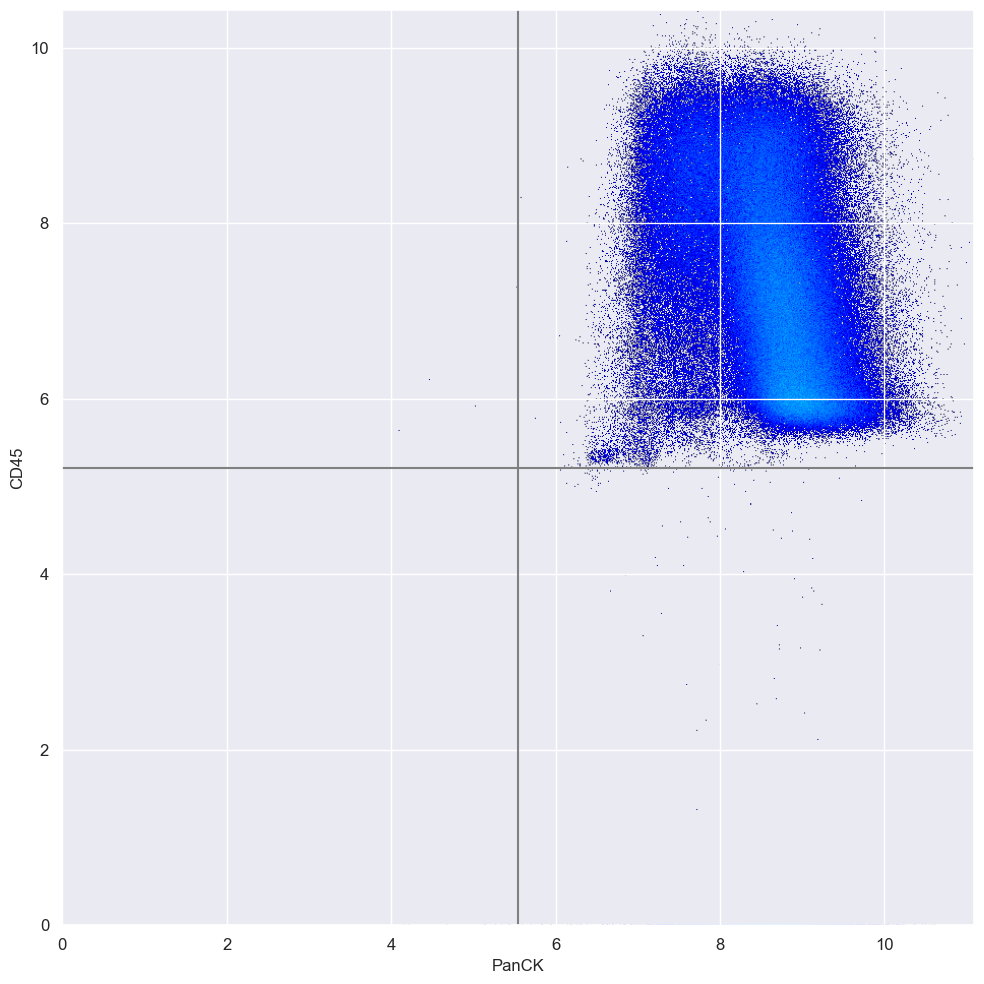

In [9]:
## Density plot to see marker distributions before gating

# ‼️UPDATE ‼️ -- Change these 2 markers to look at different combinations
marker_x = 'PanCK'   # the x axis marker
marker_y = 'CD45'     # the y axis marker

subset_to_use = adata.obs['imageid'].unique()[0] # get sample name again
print(f"Density plot: {marker_x} (x) versus {marker_y} (y)")


sm.pl.densityPlot2D( # another scimap plotting function, plots every cell as point on 2D grid 
    adata,
    marker_x, # x-axis marker (positional argument no keyword needed)
    markerB=marker_y, # y-axis marker (keyword argument)
    layer=None, # use raw unscaled data (None means use adata.X directly)
    imageid='imageid', # column that identifies the sample
    subset=subset_to_use, # only plot this sample
    ncols=None, # num of columns if making multiple plots (None = auto)
    cmap='jet', # color map; blue, green, yellow, red is low to high density
    figsize=(10, 10), # width by height of the plot (inches)
    fontsize=None, # font size for labels (None = default)
    dpi=100, # resolution of the plot (dots/inch)
    xticks=None, # custom x-axis tick marks (None = auto)
    yticks=None # custom y-axis tick marks (None = auto)
)

In [13]:
## Point to the gating and phenotyping files (these come from the configuration cell at the beginning) 

pheno_label = 'phenotype' # stores the name of the new column (assigned cell type for each cell)

# Again, this loop checks if a file actually exists at that path, returns True if found and False if not
for label, path in [('Gates',       gates_file), # csv with one row per marker and threshold intensity (set manually) 
                    ('Phenotyping', phenotyping_file)]: # csv with if/then rules for assigning cell type
    status = 'All good!' if os.path.exists(path) else 'Missing!!'
    print(f"{status} --> {label}: {path}")

print(f"\n Cell type labels will be stored in {pheno_label}")

All good! --> Gates: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\BDBAT0085\BDBAT0085_gates.csv
All good! --> Phenotyping: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\phenotyping_workflow_simple.csv

 Cell type labels will be stored in phenotype


## ‼️ NOTE:‼️

There is a manual step that must be done at some point before the following cell is run.

### Open Minerva Gater to set gates for each slide before proceeding.
1) Download Minerva Gater for your appropriate operating system (Windows or Mac): https://github.com/labsyspharm/gater
2) Open Gater. I recommend storing the .exe file in your SCIMAP working directory so it's easy to find. 
4) Go to http://localhost:8000 in browser
5) In the Gater header, select "Upload," check MCMICRO, enter path to your sample folder
6) Set gates for each marker visually, then type in the values in your gates csv

In [14]:
## Load the gates CSV file
manual_gate = pd.read_csv(gates_file) # pandas function reads CSV file and converst to dataframe 
manual_gate = manual_gate.rename(columns={'Gate': 'markers', 'BDBAT0085': 'gates'}) # these are the names scimap will be looking for 

# This is a dictionary inside adata for storing extra info
# storing gates here can help keep track of the thresholds used
adata.uns['gates'] = manual_gate # Makes an entry inside the dictionary

print("Gates loaded:")
print(manual_gate.to_string(index=False)) # prints the data frame as text without row numbers

Gates loaded:
markers  gates
    HSV   8.36
  VSV-G   8.64
     V5   8.55
    NWS   8.14
  Ollas   8.58
      S   8.30
     HA   8.33
   CD45   7.02
      C   8.03
  PanCK   8.30
    CD4   7.34
   CD8a   8.82
   PDPN   7.97
   F480   7.78
 CD161c   7.48


In [15]:
## Rescale all marker intensities using gate thresholds
# All markers end up on a 0-1 scale relative to their gate threshold
# Note that this permanently changes adata.X so the raw values are replaced

print("Rescaling marker intensities...")

# Another scimap preprocessing function, this is what normalizes each marker's intensity values relaitve to threshold
adata = sm.pp.rescale(adata, gate=manual_gate) 

print("Rescaling complete! adata.X now contains normalized 0–1 values.")


Rescaling marker intensities...
Running GMM for image: BDBAT0085
Applying GMM to markers: AF488, AF555, AF647

Scaling Image: BDBAT0085
Scaling AF488 (gate: 6.805)
Scaling AF555 (gate: 5.574)
Scaling AF647 (gate: 5.219)
Scaling HSV (gate: 8.360)
Scaling VSV-G (gate: 8.640)
Scaling V5 (gate: 8.550)
Scaling NWS (gate: 8.140)
Scaling Ollas (gate: 8.580)
Scaling S (gate: 8.300)
Scaling HA (gate: 8.330)
Scaling CD45 (gate: 7.020)
Scaling C (gate: 8.030)
Scaling PanCK (gate: 8.300)
Scaling CD4 (gate: 7.340)
Scaling CD8a (gate: 8.820)
Scaling PDPN (gate: 7.970)
Scaling F480 (gate: 7.780)
Scaling CD161c (gate: 7.480)
Rescaling complete! adata.X now contains normalized 0–1 values.


In [16]:
## Assign a cell type identity to every cell 

phenotype_rules = pd.read_csv(phenotyping_file) #pandas function reads the phenotyping rules file into a DataFrame
print(phenotype_rules.to_string(index=False))

# scimap tool function reads the rules in phenotype_rules and applies them to EVERY cell in adata !
# label=pheno_label says what to name the new column it adds to adata.obs
adata = sm.tl.phenotype_cells(adata, phenotype=phenotype_rules, label=pheno_label)

print(f"\n Phenotyping complete!")
print(f"   Column {pheno_label} has been added to adata.obs")
adata.obs

Unnamed: 0   Unnamed: 1   F480    CD4   CD8a CD161c PanCK
       all        Tumor allneg allneg allneg allneg   pos
       all  Macrophages    pos    NaN    NaN    NaN   NaN
       all CD4+ T cells    NaN    pos    NaN    NaN   NaN
       all CD8+ T cells    NaN    NaN    pos    NaN   NaN
       all     NK cells    NaN    NaN    NaN    pos   NaN
Phenotyping Tumor
Phenotyping Macrophages
Phenotyping CD4+ T cells
Phenotyping CD8+ T cells
Phenotyping NK cells
Consolidating the phenotypes across all groups

 Phenotyping complete!
   Column phenotype has been added to adata.obs


,X_centroid,Y_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,CellID,imageid,Treatment_Group,phenotype
BDBAT0085_1,3863.912752,638.174497,149.0,14.330963,13.249329,0.381122,0.931250,0.764103,1.471999,1,BDBAT0085,test_run,Tumor
BDBAT0085_2,3465.516908,714.526570,207.0,18.833414,14.001783,0.668787,0.936652,0.739286,-1.356049,2,BDBAT0085,test_run,Tumor
BDBAT0085_3,3050.022422,1033.394619,223.0,18.459338,15.380374,0.552967,0.961207,0.819853,-0.906260,3,BDBAT0085,test_run,Tumor
BDBAT0085_4,2506.576471,1764.158824,170.0,18.075014,12.167323,0.739500,0.949721,0.666667,-0.671361,4,BDBAT0085,test_run,Tumor
BDBAT0085_5,2510.019417,1772.718447,103.0,16.276087,8.575708,0.849933,0.880342,0.525510,-0.846072,5,BDBAT0085,test_run,Tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
BDBAT0085_399067,4708.460526,16801.184211,228.0,23.016359,12.687695,0.834342,0.942149,0.762542,-1.390851,399067,BDBAT0085,test_run,Tumor
BDBAT0085_399068,4111.453125,16804.718750,128.0,14.773151,11.144651,0.656432,0.914286,0.711111,-1.552599,399068,BDBAT0085,test_run,Tumor
BDBAT0085_399069,4229.641221,16814.541985,131.0,13.881165,12.030667,0.498847,0.935714,0.719780,0.465510,399069,BDBAT0085,test_run,Tumor
BDBAT0085_399070,4343.358289,16822.614973,187.0,19.559901,12.193644,0.781903,0.944444,0.820175,-1.429099,399070,BDBAT0085,test_run,Tumor


In [18]:
## Count how many cells were assigned to each cell type

# This counts how many times each unique value appears in the "phenotype" column from most to least and returns as a 2 column table
counts_df = (
    adata.obs['phenotype']
    .value_counts() # return pandas series, basically shows index --> value
    .reset_index() # return as 2 column table format

    
) 

counts_df.columns = ['phenotype', 'count'] # rename the 2 columns in the table
print(counts_df)

counts_df.to_csv(counts_csv, index=False) # save to the counts_csv file defined in config.


      phenotype   count
0         Tumor  220486
1   Macrophages  131571
2  CD8+ T cells   37099
3  CD4+ T cells    8548
4      NK cells    1226
5       Unknown     141


## Validate Phenotyping

The next step is to validate how well our gates accurately captured cells positive for each marker, and how well our phenotyping workflow accurately classified cell types. 

We will plot the distribution of the phenotypes and inspect them visually in Napari. 

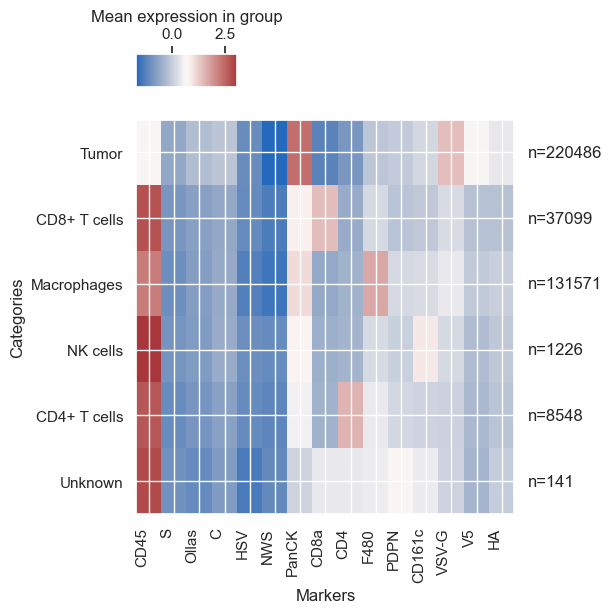

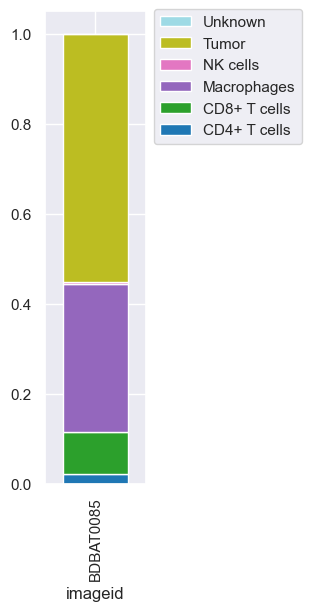

In [19]:
## Two ways of visually validating phenotyping results - sanity check
## Run both + check  outputs before moving on to ROI drawing

# Plot 1: Heat map
# Shows avg marker intensity per cell type

# A new scimap plotting function
sm.pl.heatmap(
    adata,
    groupBy=pheno_label, # rows of the heat map = cell types, grouped by phenotype column
    subsetMarkers=heatmap_markers,  # only show these markers as columns; set in configuration cell, update there if needed
    standardScale='column', # Standardize a dimension between 0 and 1 (subtract the minimum and divide each by its maximum). We are scaling each marker (column).
    showPrevalence=True, # add % of total cells next to each row label
    figsize=(6, 6),
    saveDir=None,
    fileName=None)

# Plot 2: Stacked bar chart
# Shows what % of cells in this sample are each cell type


# New scimap plotting function
sm.pl.stacked_barplot(
    adata,
    x_axis='imageid', # one bar per sample 
    y_axis=pheno_label, # stack the bar by cell type
    method='percent', #percentages, not raw counts so bar always adds to 100%
    plot_tool='matplotlib', # this module is used to render the plot
    matplotlib_cmap='tab20', # color scheme, 20 dif colors
    figsize=(3, 6),
    edgecolor='white'
)

In [20]:
## Open napari to look at phenotyping results overlaid on tissue image
# 1 dot per cell -- each is colored by its assigned cell type

os.chdir(working_dir)

subset_to_use = adata.obs['imageid'].unique()[0] # get sample id again from adata

print(f"Now opening napari with phenotype overlay for: {subset_to_use}")
print("Close napari when done!")

# Same scimap plotting function, except here we have overlay=pheno_label
sm.pl.image_viewer( 
    tif_path,            
    adata,                 
    overlay=pheno_label,  # Different from before - tells napari add a colored point layer on top of tissue image where each dot = cell 
    point_size=15,         
    imageid='imageid',    
    subset=subset_to_use   
)

Now opening napari with phenotype overlay for: BDBAT0085
Close napari when done!


## Draw Regions of Interest (ROIs)

Within each image, there will likely be multiple ROIs that we will want to analyze separately. 

For example, if a slide image contained both tumor and spleen, we would create one ROI encompassing the tumor and one encompassing the spleen. 

Using the below code, we draw our ROIs in Napari, which will automatically save the coordinates of the ROI to our <adata.obs> object.

In [21]:
## Draw ROI1
# Draw region in napari by going to shapes layer --> polygon tool; close the window when done to move on
# The region you drew gets saved as a column called "ROI1" in adata.obs

adata.obs_names_make_unique()  # Fix any duplicate cell indexes that may cause issues
os.chdir(working_dir) #navigate here first
print("Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI2")


# Another scimap plot function! 
adata = sm.pl.addROI_image(
    tif_path,
    adata,
    subset=sample_id,  # sample to display
    imageid='imageid', # column to identify the sample
    overlay=pheno_label, # Show cell type colors while drawing, easier to draw meaningful regions
    overlay_category=None,  # show all categories (None means don't filter anything)
    markers=None,  # which marker channels to load (None means default)
    channel_names='default',  # use default channel naming from the tif file
    x_coordinate='X_centroid', # column in adata.obs for the cell's x position
    y_coordinate='Y_centroid', # same, but for y position
    seg_mask=None, # 
    overwrite=False, # False = don't overwrite if ROI1 already exists, set true if you need to redraw this ROI1
    label='ROI1' # name of  new column added to adata.obs
)
print(" ROI1 saved to adata.obs!!")

Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI2

        Opening Napari;
        Add shape layers (on left) to draw ROI's. 
        Rename the shape layer to give a name to your ROI
        Multiple shape layers are supported
        ROI's should not overlap
        Close Napari to save ROI's.
        
Identifying cells within selected ROI's
ROIs saved under adata.obs['ROI1']
 ROI1 saved to adata.obs!!


In [22]:
## Same thing, but draw ROI2

adata.obs_names_make_unique()
os.chdir(working_dir) 
print("Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI3")

adata = sm.pl.addROI_image(
    tif_path,
    adata,
    subset=sample_id, 
    imageid='imageid', 
    overlay=pheno_label, 
    overlay_category=None, 
    markers=None, 
    channel_names='default',  
    x_coordinate='X_centroid', 
    y_coordinate='Y_centroid', 
    seg_mask=None, 
    overwrite=False, 
    label='ROI2' 
)
print(" ROI2 saved to adata.obs!!")

Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI3

        Opening Napari;
        Add shape layers (on left) to draw ROI's. 
        Rename the shape layer to give a name to your ROI
        Multiple shape layers are supported
        ROI's should not overlap
        Close Napari to save ROI's.
        
Identifying cells within selected ROI's
ROIs saved under adata.obs['ROI2']
 ROI2 saved to adata.obs!!


In [23]:
## Again, same thing, but draw ROI3


os.chdir(working_dir) 
print("Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI4")

adata = sm.pl.addROI_image(
    tif_path,
    adata,
    subset=sample_id, 
    imageid='imageid', 
    overlay=pheno_label, 
    overlay_category=None, 
    markers=None, 
    channel_names='default',  
    x_coordinate='X_centroid', 
    y_coordinate='Y_centroid', 
    seg_mask=None, 
    overwrite=False, 
    label='ROI3' 
)
print(" ROI3 saved to adata.obs!!")

Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI4

        Opening Napari;
        Add shape layers (on left) to draw ROI's. 
        Rename the shape layer to give a name to your ROI
        Multiple shape layers are supported
        ROI's should not overlap
        Close Napari to save ROI's.
        
Identifying cells within selected ROI's
ROIs saved under adata.obs['ROI3']
 ROI3 saved to adata.obs!!


In [24]:
## Finally, set ROI4!


os.chdir(working_dir) 
print("Navigate to napari window and draw your region --> close napari")

adata = sm.pl.addROI_image(
    tif_path,
    adata,
    subset=sample_id, 
    imageid='imageid', 
    overlay=pheno_label, 
    overlay_category=None, 
    markers=None, 
    channel_names='default',  
    x_coordinate='X_centroid', 
    y_coordinate='Y_centroid', 
    seg_mask=None, 
    overwrite=False, 
    label='ROI4' 
)
print(" ROI4 saved to adata.obs!!")

Navigate to napari window and draw your region --> close napari

        Opening Napari;
        Add shape layers (on left) to draw ROI's. 
        Rename the shape layer to give a name to your ROI
        Multiple shape layers are supported
        ROI's should not overlap
        Close Napari to save ROI's.
        
Identifying cells within selected ROI's
ROIs saved under adata.obs['ROI4']
 ROI4 saved to adata.obs!!


In [25]:
# Save these ROI selections right after, b/c this is a manual step!
# Would have to redraw each ROI if there was a crash
os.chdir(analysis_dir)
adata.write(adata_checkpoint, compression=None) # overwrites previous checkpoint, now includes all 4 ROI columns in adata.obs
print(f"adata saved with ROI annotations!")


adata saved with ROI annotations!


In [26]:
## Combine each ROI column into one unified ROI column + filter to only keep cells inside your drawn regions

# Nice list comprehension that builds the list ['ROI1', 'ROI2', 'ROI3', 'ROI4'] (or however many based on what you set n_rois at top)
roi_labels = [f'ROI{i}' for i in range(1, n_rois + 1)]

# This is a numpy func -- works like np.where(condition, value_if_true, value_if_false)
# However here 4 of them are NESTED -- this checks EACH ROI column in order:
# If this cell is ROI, label it ROI1. If not, check if ROI2 (label it ROI2 if yes). If not, check if ROI3... If none, label it "OTher"

adata.obs['ROI'] = np.where(adata.obs['ROI1'] == 'ROI1', 'ROI1',
                       np.where(adata.obs['ROI2'] == 'ROI2', 'ROI2',
                           np.where(adata.obs['ROI3'] == 'ROI3', 'ROI3',
                               np.where(adata.obs['ROI4'] == 'ROI4', 'ROI4', 'Other')))) 

# Filter adata to only cells inside ROI
# adata[boolean_mask] is called boolean indexing. This keeps only rows where the mask is True

adata1 = adata[adata.obs['ROI'].isin(roi_labels)].copy() # here, the mask checks each Cell's ROI value against the list, 
                                                         # and returns True if in list and False if not ("Other")
                                                         # Makes a copy of adata called adata1

print(f"Total cells in full adata: {adata.n_obs:,}")
print(f"Cells inside ROIs (adata1): {adata1.n_obs:,}")
print("Cells per ROI:")
print(adata1.obs['ROI'].value_counts().to_string()) #count num of times each unique value appears in the ROI column, convert to text
adata1.obs 

Total cells in full adata: 399,071
Cells inside ROIs (adata1): 66,342
Cells per ROI:
ROI
ROI1    22994
ROI3    16916
ROI2    16027
ROI4    10405


,X_centroid,Y_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,CellID,imageid,Treatment_Group,phenotype,ROI1,ROI2,ROI3,ROI4,ROI
BDBAT0085_1850,6018.371429,771.308571,175.0,18.701089,11.977176,0.767997,0.935829,0.643382,0.793270,1850,BDBAT0085,test_run,Tumor,ROI1,Other,Other,Other,ROI1
BDBAT0085_1851,6115.346667,771.080000,150.0,14.797354,13.275531,0.441714,0.882353,0.666667,-0.303290,1851,BDBAT0085,test_run,Tumor,ROI1,Other,Other,Other,ROI1
BDBAT0085_1853,4814.797546,772.723926,163.0,16.409077,12.924820,0.616106,0.900552,0.727679,-0.456697,1853,BDBAT0085,test_run,Tumor,ROI1,Other,Other,Other,ROI1
BDBAT0085_1855,5434.230088,770.849558,113.0,12.853662,11.223350,0.487427,0.918699,0.724359,-1.197740,1855,BDBAT0085,test_run,CD8+ T cells,ROI1,Other,Other,Other,ROI1
BDBAT0085_1856,5479.992754,772.231884,138.0,16.747414,10.770158,0.765787,0.920000,0.718750,-0.364759,1856,BDBAT0085,test_run,Tumor,ROI1,Other,Other,Other,ROI1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BDBAT0085_388187,4443.233766,15940.168831,77.0,11.034507,8.916649,0.589087,0.927711,0.712963,-1.541081,388187,BDBAT0085,test_run,Macrophages,Other,Other,Other,ROI4,ROI4
BDBAT0085_388191,4700.763441,15940.516129,93.0,11.879952,10.038073,0.534831,0.948980,0.845455,1.310513,388191,BDBAT0085,test_run,Unknown,Other,Other,Other,ROI4,ROI4
BDBAT0085_388194,4954.813725,15940.529412,102.0,15.958890,8.262822,0.855528,0.918919,0.796875,-1.559064,388194,BDBAT0085,test_run,Macrophages,Other,Other,Other,ROI4,ROI4
BDBAT0085_388195,5006.275862,15939.879310,58.0,9.299098,7.935533,0.521312,0.935484,0.805556,0.406368,388195,BDBAT0085,test_run,Macrophages,Other,Other,Other,ROI4,ROI4


In [27]:
## Remove cells labeled 'Unknown' from the ROI data

before = adata1.n_obs # number of cells initially

adata1 = adata1[
    ~adata1.obs['phenotype'].isin(['Unknown']) # ~ is the NOT operator -- flips True to False, False to True
                                               # so this boolean mask is True for everything EXCEPT Unknown cells
].copy() # Creating a copy of adata1 with everything EXCEPT unknwon cells

after = adata1.n_obs


print(f"Cells before: {before:,}")
print(f"Cells after: {after:,}")


Cells before: 66,342
Cells after: 66,316


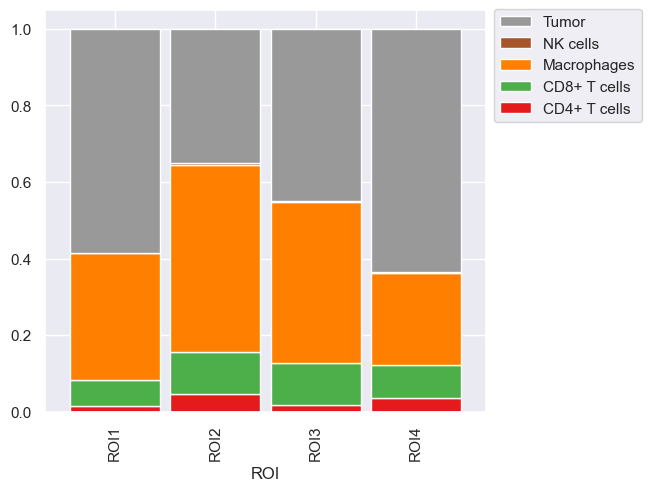

In [28]:
## Stacked bar chart, compares cell type composition between ROIs
# basically function as the earlier barplot but now we apply to adata1 (just ROIs)

sm.pl.stacked_barplot(
    adata1,              
    x_axis='ROI',        # one bar per ROI side by side
    y_axis=pheno_label,  # stack by cell type
    method='percent'     # normalize to 100% 
)

In [29]:
## Add genotype label and save the final processed file

adata1.obs['genotype'] = genotype # make new column in adata1.obs, fill every row with whatever genotype you set in configuration


adata1.write(adata_final)
print(f"Saved to: {adata_final}")

# Nice final summary!
print("STEP 1 COMPLETE")
print(f"Sample: {sample_id}")
print(f"Genotype: {genotype}")
print(f"Cells in ROIs: {adata1.n_obs:,}")
print(f"Cell types: {adata1.obs['phenotype'].nunique()}") # counts num of unique values in this column, returns a single number
print(f"Output file: {adata_final}")
print("Next, you can move onto step2_nopc_immunedensity.ipynb")

Saved to: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\analysis\scimap_results\adata_tocombine\adata_BDBAT0085.h5ad
STEP 1 COMPLETE
Sample: BDBAT0085
Genotype: test_run
Cells in ROIs: 66,316
Cell types: 5
Output file: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis\analysis\scimap_results\adata_tocombine\adata_BDBAT0085.h5ad
Next, you can move onto step2_nopc_immunedensity.ipynb
